In [1]:
%reset -f
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Shapes_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding, PyGGraphWrapper
from torch_geometric.loader import DataLoader as PyGDataLoader
from matplotlib import patches
import src.plot as custom_plot
import src.diffusion as diffusion
import src.sde as sde
from matplotlib.collections import LineCollection

/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project_path = os.path.abspath('')
print(project_path)
print(torch.cuda.is_available())

/Users/jizho/project_codes/diffusion-playground
False



=== Variable num_points ===
  batch.x.shape:          torch.Size([72, 2])
  batch.pos.shape:        torch.Size([72, 2])
  batch.edge_index.shape: torch.Size([2, 586])
  batch.edge_attr.shape:  torch.Size([586, 2])
  batch.batch.shape:      torch.Size([72])
  sample 1's edge num:    torch.Size([56, 2])
  per-graph node counts:  [9, 8, 11, 8, 8, 8, 10, 10]

Done.


/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_58610/3380746020.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(xs[:,0], xs[:,1], c="steelblue", cmap="viridis")


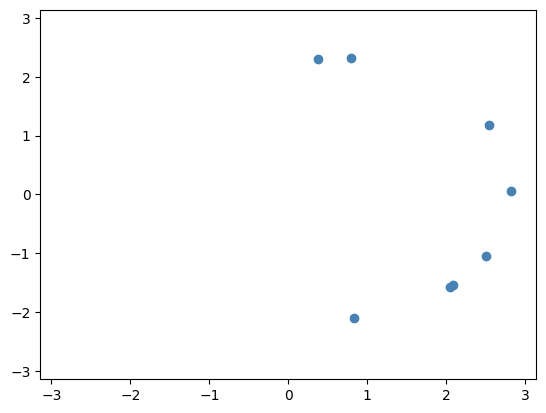

/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_58610/3380746020.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0, i].scatter(v_list[i][:,0], v_list[i][:,1], c="steelblue", cmap="viridis")
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_58610/3380746020.py:52: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1, i].scatter(pos_list[i][:,0], pos_list[i][:,1], c="steelblue", cmap="viridis")
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_58610/3380746020.py:68: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[2, i].scatter(xs[:,0], xs[:,1], c="red", cmap="viridis", alpha=0.5)
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_58610/3380746020.py:69: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[2, i].scatter(pos_list[i][:,0], pos_list[i][:,1], c="black

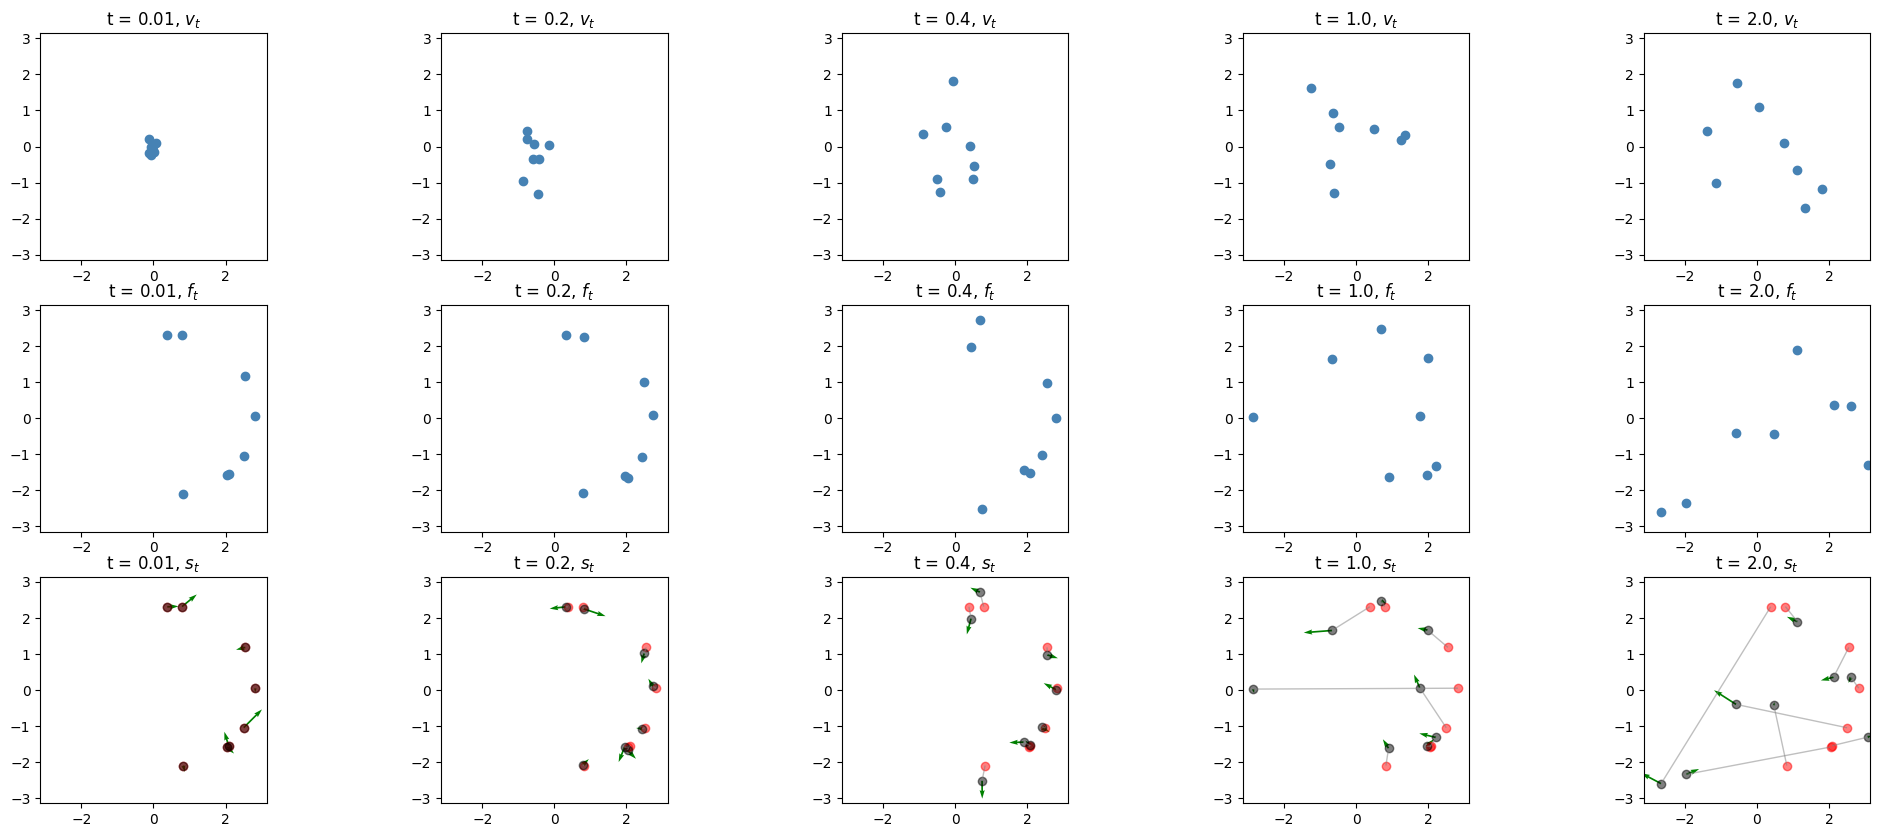

In [7]:
shape_dataset = Shapes_Dataset(num_points=1000, dataset_size=10000, shape_types=["circle","rectangle","triangle"])
graph_dataset = PyGGraphWrapper(shape_dataset, num_points_range=(8,12))
graph_dataloader = PyGDataLoader(graph_dataset, batch_size=8, shuffle=True)
batch_1_graph = next(iter(graph_dataloader))
edge_graph = batch_1_graph.batch[batch_1_graph.edge_index[0]]
print("\n=== Variable num_points ===")
print(f"  batch.x.shape:          {batch_1_graph.x.shape}")
print(f"  batch.pos.shape:        {batch_1_graph.pos.shape}")
print(f"  batch.edge_index.shape: {batch_1_graph.edge_index.shape}")
print(f"  batch.edge_attr.shape:  {batch_1_graph.edge_attr.shape}")
print(f"  batch.batch.shape:      {batch_1_graph.batch.shape}")
print(f"  sample 1's edge num:    {batch_1_graph.edge_attr[edge_graph == 1].shape}")
# show per-graph node counts
counts = batch_1_graph.batch.bincount()
print(f"  per-graph node counts:  {counts.tolist()}")
print("\nDone.")

mask = batch_1_graph.batch == 1
xs = batch_1_graph.x[mask]
fig, ax = plt.subplots()
ax.scatter(xs[:,0], xs[:,1], c="steelblue", cmap="viridis")
ax.set_xlim(-torch.pi,torch.pi)
ax.set_ylim(-torch.pi,torch.pi)
plt.show()



TDMmodel = diffusion.TDMDiffusion(dim=2, integrator_type="Euler", trunc_n=13, f_scale=2*torch.pi, total_time=2.0, simplified_param=True, n_sigma_rs=2000)

time_steps = [0.01,0.2,0.4,1.0,2.0]

v_list = []
pos_list = []
score_list = []
for t_step in time_steps:
    noised_sample_batch, score_batch, t_batch = TDMmodel.sample_forward_graph(batch_1_graph, 2.0, t_dist_kw="constant", v0_dist_kw="zero",constant_t = t_step, return_time=True)
    vt_batch, noised_graph_batch = noised_sample_batch
    mask = noised_graph_batch.batch == 1
    v_list.append(vt_batch[mask])
    pos_list.append(noised_graph_batch.pos[mask])
    score_list.append(score_batch[mask])


fig, axs = plt.subplots(3, 5, figsize=(25, 10))

for i, t_step in enumerate(time_steps):
    axs[0, i].scatter(v_list[i][:,0], v_list[i][:,1], c="steelblue", cmap="viridis")
    axs[0, i].set_title(f"t = {t_step}, $v_t$")
    axs[0, i].set_aspect("equal")
    axs[0, i].set_xlim(-torch.pi,torch.pi)
    axs[0, i].set_ylim(-torch.pi,torch.pi)
    axs[1, i].scatter(pos_list[i][:,0], pos_list[i][:,1], c="steelblue", cmap="viridis")
    axs[1, i].set_aspect("equal")
    axs[1, i].set_title(f"t = {t_step}, $f_t$")
    axs[1, i].set_xlim(-torch.pi,torch.pi)
    axs[1, i].set_ylim(-torch.pi,torch.pi)

    t = torch.tensor([t_step])
    prefactor = TDMmodel._get_prefector(t)
    sigma_norm_r_t = torch.sqrt(TDMmodel._sigma_norm_t(t))
    sigma_v = TDMmodel.sde.sigma_t(t)
    scorev_reverse = score_list[i] * prefactor * sigma_norm_r_t - v_list[i] / (sigma_v**2)
    segments = np.stack([pos_list[i], xs], axis=1)
    lc = LineCollection(segments, colors="gray", alpha=0.5,linewidths=1)
    axs[2, i].add_collection(lc)

    axs[2, i].quiver(pos_list[i][:,0], pos_list[i][:,1], score_list[i][:,0], score_list[i][:,1], color="green", cmap="viridis")
    axs[2, i].scatter(xs[:,0], xs[:,1], c="red", cmap="viridis", alpha=0.5)
    axs[2, i].scatter(pos_list[i][:,0], pos_list[i][:,1], c="black", cmap="viridis", alpha=0.5)
    axs[2, i].set_aspect("equal")
    axs[2, i].set_title(f"t = {t_step}, $s_t$")
    axs[2, i].set_xlim(-torch.pi,torch.pi)
    axs[2, i].set_ylim(-torch.pi,torch.pi)

plt.show()
